In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

# Requires seaborn in addition to requirements.txt packages
import math
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import evaluation

# --- Plot style configuration ---
plt.style.use("default")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.5
plt.rcParams["figure.figsize"] = [12, 10]
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

# --- Load data from final_returns folder ---
df = evaluation.load_results_dataframe(results_dir="final_returns2")
df.head()

,final_returns,final_returns_mean,final_returns_std,final_scores,final_scores_mean,final_scores_std,algorithm,dataset,datetime,seed,...,ent_coef_init,actor_entropy_coef,critic_entropy_coef,model_path,dataset_sample_ratio,rollout_interval,rollout_length,rollout_batch_size,model_retain_epochs,step_penalty_coef
0,"[13887.862044012534, 13622.528637794798, 3041....",12327.885415503599,3058.328595376429,"[114.1187013948677, 111.98153198939877, 26.756...",101.55362573696121,24.633785843557376,unifloral_bc,mujoco/halfcheetah/medium-v0,2026-09-28 10:53:51,3,...,1.0,0.0,0.0,,1.0,1000,5,50000,5,0.5
1,"[15090.036213258587, -362.606770083155, 15042....",14686.70991064532,1684.4932980056353,"[123.80180120194346, -0.663927740350752, 123.4...",120.55314643715808,13.568014640647567,unifloral_bc,mujoco/halfcheetah/medium-v0,2026-09-28 10:53:52,1,...,1.0,0.0,0.0,,1.0,1000,5,50000,5,0.5
2,"[14551.659440514462, 14617.165208850174, 14589...",14351.74025422683,1424.698798873206,"[119.46536131024112, 119.99298776317988, 119.7...",117.8550809667643,11.475459228309735,unifloral_bc,mujoco/halfcheetah/medium-v0,2026-09-28 10:54:01,2,...,1.0,0.0,0.0,,1.0,1000,5,50000,5,0.5
3,"[13974.413764190518, 14472.371000595072, 14435...",13536.669180419438,2548.2569332800695,"[114.81584575747128, 118.82672017410003, 118.5...",111.28996356577476,20.52533389109393,unifloral_bc,mujoco/halfcheetah/medium-v0,2026-09-28 10:54:07,0,...,1.0,0.0,0.0,,1.0,1000,5,50000,5,0.5
4,"[2726.394045790426, 14363.124557432873, 14437....",13874.678007316861,2156.2006625705726,"[24.2169122988269, 117.94677761688219, 118.544...",114.01250850996784,17.367455360355873,unifloral_bc,mujoco/halfcheetah/medium-v0,2026-09-28 10:54:11,4,...,1.0,0.0,0.0,,1.0,1000,5,50000,5,0.5


In [2]:
# --- Define bandit evaluation and plotting ---
def plot_trial(final_scores, num_subsample=8, **kwargs):
    # Run multiple bandit trials and compute confidence intervals
    runs = np.stack(final_scores.values)
    res = evaluation.bootstrap_bandit_trials(
        runs, num_subsample=num_subsample, n_bootstraps=2000, num_repeats=500
    )

    # Plotting
    line = plt.semilogx(res["pulls"], res["estimated_bests_mean"], **kwargs)
    plt.fill_between(
        res["pulls"],
        res["estimated_bests_ci_low"],
        res["estimated_bests_ci_high"],
        alpha=0.3,
        color=line[0].get_color(),
    )

Running bandit evaluation... Done.


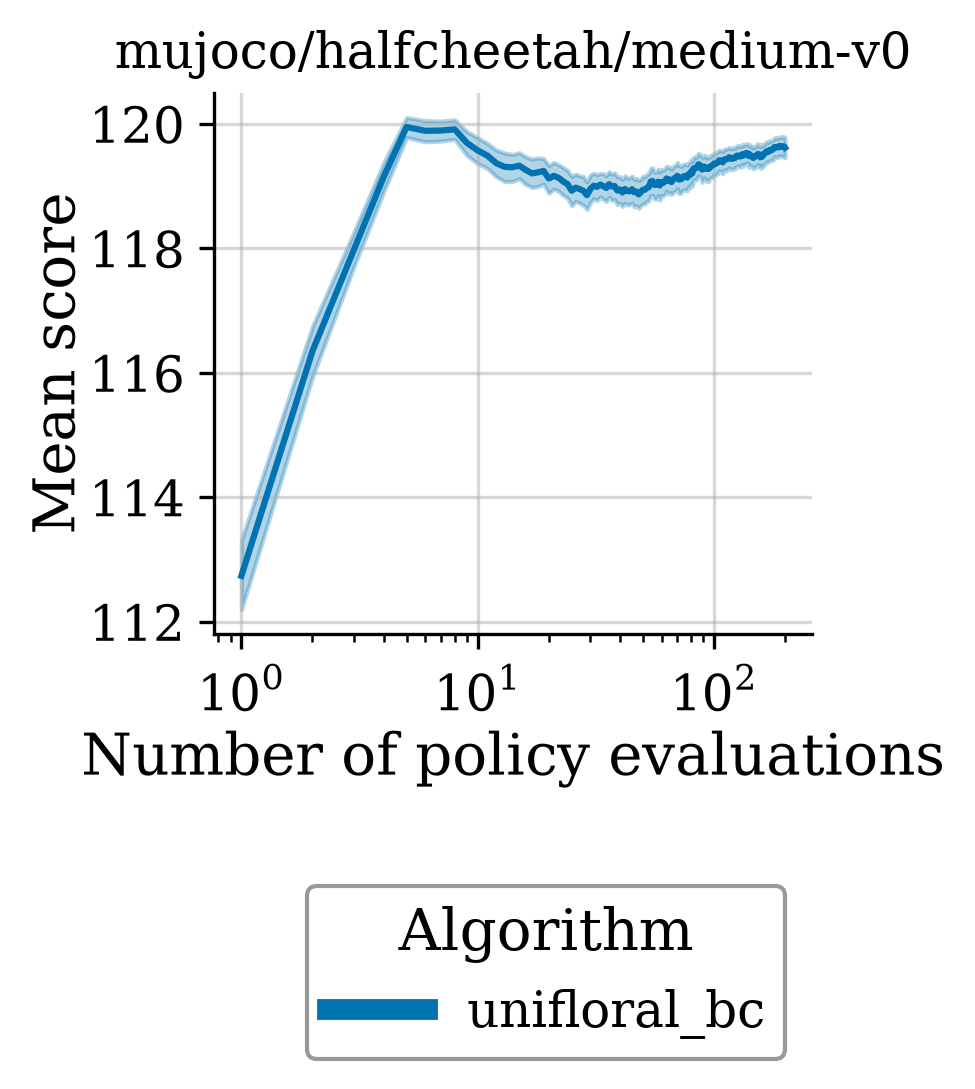

In [3]:
# --- Filter dataframe (optional) ---
plot_df = df
# E.g. plot_df = df.loc[df['algorithm'] != 'td3_bc']

# --- Run and plot bandit evaluation ---
ALGORITHM_COLOR_DICT = {algo: col for algo, col in zip(
    plot_df['algorithm'].unique(), sns.color_palette("colorblind"))}
plot_df["dataset"] = pd.Categorical(plot_df["dataset"])
num_datasets = len(plot_df["dataset"].unique())
num_algorithms = len(plot_df["algorithm"].unique())
g = sns.FacetGrid(
    plot_df,
    col="dataset",
    hue="algorithm",
    col_wrap=math.ceil(np.sqrt(num_datasets)),
    sharex=False,
    sharey=False,
    palette=ALGORITHM_COLOR_DICT,
)
print("Running bandit evaluation... ", end='')
g.map(plot_trial, "final_scores")
print("Done.")

# --- Format combined plot ---
# Remove individual x and y labels
for ax in g.axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(ax.get_title().replace("dataset = ", ""))

# Add and format big axis for shared labels
fig = plt.gcf()
big_ax = fig.add_subplot(111, frameon=False)
big_ax.tick_params(labelcolor="none", top=False, bottom=False, left=False, right=False)
big_ax.grid(False)
plt.xlabel("Number of policy evaluations")
plt.ylabel("Mean score")

# Add and format legend
g.add_legend(title="Algorithm")
leg = g._legend
for line, text in zip(leg.get_lines(), leg.get_texts()):
    line.set_linewidth(5.0)
sns.move_legend(
    g,
    "upper center",
    bbox_to_anchor=(0.45, 0.0),
    ncol=1+(num_algorithms//2),
    frameon=True,
    edgecolor="gray",
    fancybox=True,
    shadow=False,
)

# Save the figure
plt.savefig("evaluation_plots.pdf", bbox_inches="tight")